In [1]:
# %matplotlib inline

import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import torch
import deepinv as dinv

import sirf.STIR as pet
from sirf.Utilities import examples_data_path

from cil.optimisation.functions import SVRGFunction
print(SVRGFunction)

import inspect
from cil.optimisation.functions import SVRGFunction
print(inspect.signature(SVRGFunction))
#help(SVRGFunction)

from tqdm.notebook import tqdm

<class 'cil.optimisation.functions.SVRGFunction.SVRGFunction'>
(functions, sampler=None, snapshot_update_interval=None, store_gradients=False)


In [2]:
# helper functions

def plot_2d_image(idx, vol, title, clims=None, cmap="viridis"):
    plt.subplot(*idx)
    plt.imshow(vol, cmap=cmap)
    if clims is not None:
        plt.clim(clims)
    plt.colorbar(shrink=0.4)
    plt.title(title)
    plt.axis("off")

def make_positive(image_array):
    image_array[image_array < 0] = 0
    return image_array

def make_cylindrical_FOV(image):
    trunc = pet.TruncateToCylinderProcessor()
    trunc.apply(image)

In [3]:
# data path and STIR logging

#data_path = os.path.join(examples_data_path('PET'), 'thorax_single_slice')
examples_data_path_PET = '/opt/SIRF-SuperBuild/INSTALL/share/SIRF-3.9/data/examples/PET'
data_path = os.path.join(examples_data_path_PET, 'thorax_single_slice')
msg_red = pet.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')


print("Data path:", data_path)

Data path: /opt/SIRF-SuperBuild/INSTALL/share/SIRF-3.9/data/examples/PET/thorax_single_slice


In [4]:
# read images

#image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * 0.05
#image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * 0.2
image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * 0.4
attn_image = pet.ImageData(os.path.join(data_path, 'attenuation.hv'))
template = pet.AcquisitionData(os.path.join(data_path, 'template_sinogram.hs'))

cmax = image.max() * 0.6
print("Image shape:", image.dimensions())

Image shape: (np.int32(1), np.int32(155), np.int32(155))


In [5]:
# create attenuation model

acq_model_for_attn = pet.AcquisitionModelUsingRayTracingMatrix()
asm_attn = pet.AcquisitionSensitivityModel(attn_image, acq_model_for_attn)
asm_attn.set_up(template)

attn_factors = asm_attn.forward(template.get_uniform_copy(1))
asm_attn = pet.AcquisitionSensitivityModel(attn_factors)

In [6]:
# create acquisition model

acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
acq_model.set_num_tangential_LORs(5)
#acq_model.set_acquisition_sensitivity(asm_attn)
acq_model.set_up(template, image)

In [7]:

# simulate PET acquisition data
'''
acquired_data = acq_model.forward(image)

obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun.set_acquisition_model(acq_model)
'''

'\nacquired_data = acq_model.forward(image)\n\nobj_fun = pet.make_Poisson_loglikelihood(acquired_data)\nobj_fun.set_acquisition_model(acq_model)\n'

In [8]:
# simulate PET acquisition data and add Poisson noise

acquired_data_clean = acq_model.forward(image)

acq_arr = acquired_data_clean.as_array().astype(np.float32)
acq_arr_noisy = np.random.poisson(acq_arr).astype(np.float32)

acquired_data = acquired_data_clean.clone()
acquired_data.fill(acq_arr_noisy)

obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun.set_acquisition_model(acq_model)


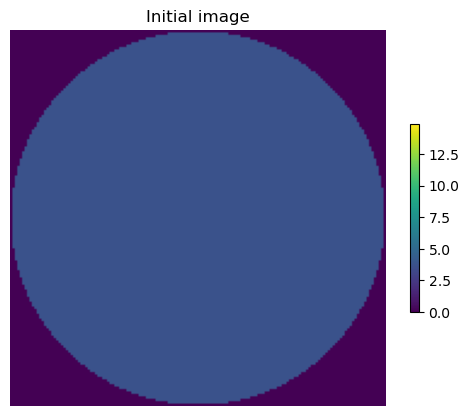

In [9]:
# create reconstructor and initial image

recon = pet.OSMAPOSLReconstructor()
recon.set_num_subsets(4)

initial_image = image.get_uniform_copy(cmax / 4)
make_cylindrical_FOV(initial_image)

im_slice = initial_image.dimensions()[0] // 2

plt.figure(figsize=(5, 5))
plot_2d_image([1, 1, 1], initial_image.as_array()[im_slice, :, :], "Initial image", [0, cmax])
plt.tight_layout()

In [10]:
# run reconstruction without RDP prior

num_subiters = 100

obj_fun_no_prior = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun_no_prior.set_acquisition_model(acq_model)

recon.set_objective_function(obj_fun_no_prior)
recon.set_num_subiterations(num_subiters)
recon.set_up(initial_image)
recon.set_current_estimate(initial_image)
recon.process()

reconstructed_image_no_prior = recon.get_output()

In [11]:
# RDP prior
prior = pet.RelativeDifferencePrior()
prior.set_penalisation_factor(0.3)
prior.set_gamma(2.0)
prior.set_epsilon(1e-3)
prior.set_kappa(initial_image.get_uniform_copy(1.0))

# objective with RDP
obj_fun_rdp = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun_rdp.set_acquisition_model(acq_model)
obj_fun_rdp.set_prior(prior)

recon.set_objective_function(obj_fun_rdp)
recon.set_num_subiterations(num_subiters)
recon.set_up(initial_image)
recon.set_current_estimate(initial_image)
recon.process()

reconstructed_image_rdp = recon.get_output()

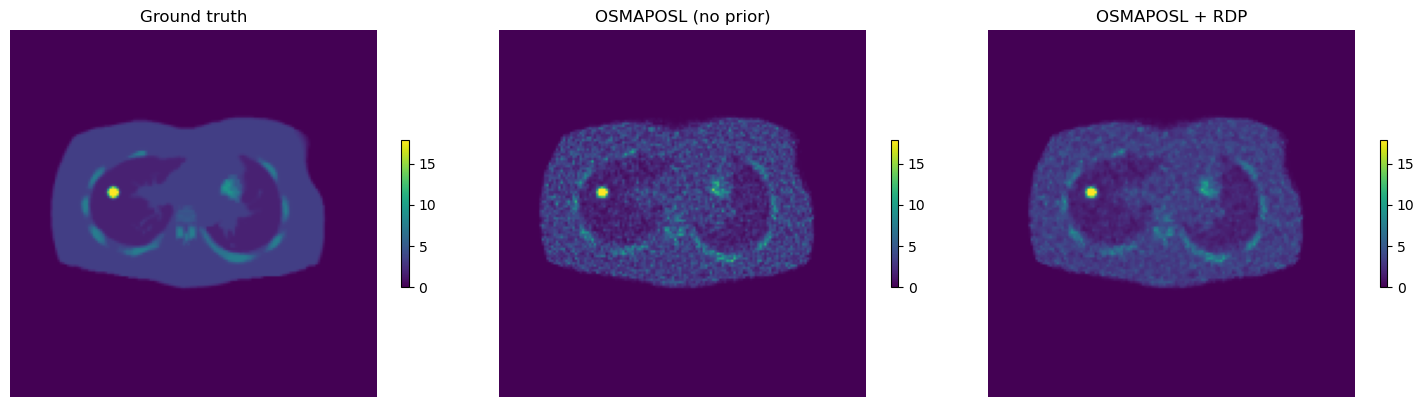

In [12]:
# show GT, OSMAPOSL without prior, and OSMAPOSL + RDP

plt.figure(figsize=(15, 4))

plot_2d_image(
    [1, 3, 1],
    image.as_array()[im_slice, :, :],
    "Ground truth",
    [0, cmax * 1.2]
)

plot_2d_image(
    [1, 3, 2],
    reconstructed_image_no_prior.as_array()[im_slice, :, :],
    "OSMAPOSL (no prior)",
    [0, cmax * 1.2]
)

plot_2d_image(
    [1, 3, 3],
    reconstructed_image_rdp.as_array()[im_slice, :, :],
    "OSMAPOSL + RDP",
    [0, cmax * 1.2]
)

plt.tight_layout()

In [13]:
# load DRUNet

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

denoiser = dinv.models.DRUNet(
    in_channels=1,
    out_channels=1,
    pretrained="download"
).to(device)

#denoiser.eval()

Device: cuda


In [14]:
# take one reconstructed PET slice and denoise it once with DRUNet

#slice2d = reconstructed_image.as_array()[im_slice, :, :].astype(np.float32)
slice2d = reconstructed_image_no_prior.as_array()[im_slice, :, :].astype(np.float32)
smin = slice2d.min()
smax = slice2d.max()
slice2d_norm = (slice2d - smin) / (smax - smin + 1e-8)


x = torch.tensor(slice2d_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    x_denoised = denoiser(x, sigma=0.05)

slice2d_denoised = x_denoised.squeeze().detach().cpu().numpy()
slice2d_denoised = slice2d_denoised * (smax - smin) + smin

In [15]:
# helper: DRUNet denoise a whole 3D volume slice-by-slice

def drunet_denoise_volume_2p5d(vol3d, denoiser, device, sigma=0.05):
    vol_out = np.zeros_like(vol3d, dtype=np.float32)

    for z in range(vol3d.shape[0]):
        slice2d = vol3d[z, :, :].astype(np.float32)

        smin = slice2d.min()
        smax = slice2d.max()
        slice2d_norm = (slice2d - smin) / (smax - smin + 1e-8)

        x = torch.tensor(slice2d_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            x_denoised = denoiser(x, sigma=sigma)

        out = x_denoised.squeeze().detach().cpu().numpy()
        out = out * (smax - smin) + smin
        vol_out[z, :, :] = out

    return vol_out

In [16]:
# CIL's built-in SVRGFunction

eps = 1e-6
num_subsets = 4

ones_acq = acquired_data.get_uniform_copy(1.0)
sens_img = acq_model.backward(ones_acq)
sens_arr = sens_img.as_array().astype(np.float32)

class STIRSubsetFunction:
    def __init__(self, obj_fun, subset_idx):
        self.obj_fun = obj_fun
        self.subset_idx = subset_idx

    def __call__(self, x):
        # full objective value is enough for monitoring
        return self.obj_fun.value(x)

    def gradient(self, x, out=None):
        g = self.obj_fun.gradient(x, self.subset_idx)
        if out is not None:
            out.fill(g)
            return out
        return g
obj_fun_no_prior.set_up(initial_image)
subset_functions = [STIRSubsetFunction(obj_fun_no_prior, s) for s in range(num_subsets)]

svrg_obj = SVRGFunction(
    subset_functions,
    snapshot_update_interval=num_subsets
)

def cil_svrg_step(current_image, alpha=1.0):
    x_arr = current_image.as_array().astype(np.float32)

    # CIL computes the SVRG gradient estimator internally
    grad_img = svrg_obj.gradient(current_image)
    grad_arr = grad_img.as_array().astype(np.float32)

    # keep your PET-style diagonal preconditioner
    P = x_arr / (sens_arr + eps)

    x_new = x_arr + alpha * P * grad_arr
    x_new[x_new < 0] = 0

    out = current_image.clone()
    out.fill(x_new)
    make_cylindrical_FOV(out)
    return out


In [25]:
# SVRG-PnP loop using CIL's SVRGFunction

num_pnp_iters = 100
sigma_denoiser = 3.0/255.0
alpha = 0.2

current_image = initial_image.clone()

obj_fun_no_prior.set_up(current_image)

pnp_objective_values = [obj_fun_no_prior.value(current_image)]

all_pnp_images = np.ndarray(
    shape=(num_pnp_iters + 1,) + current_image.as_array().shape,
    dtype=np.float32
)

all_pnp_images[0] = current_image.as_array()

for i in range(1, num_pnp_iters + 1):

    # 1) SVRG data-consistency step
    current_image = cil_svrg_step(current_image, alpha=alpha)

    # 2) DRUNet denoising every 5 iterations
    if i % 5 == 0:
        vol = current_image.as_array().astype(np.float32)
        vol_denoised = drunet_denoise_volume_2p5d(
            vol, denoiser, device, sigma=sigma_denoiser
        )

        # soft blending to reduce oversmoothing
        lam = 0.35
        vol = (1 - lam) * vol + lam * vol_denoised

        vol = make_positive(vol)
        current_image.fill(vol)
        make_cylindrical_FOV(current_image)

    # 3) store
    pnp_objective_values.append(obj_fun_no_prior.value(current_image))
    all_pnp_images[i] = current_image.as_array()

Reconstructing PnP images:   0%|          | 0/8 [00:00<?, ?it/s]

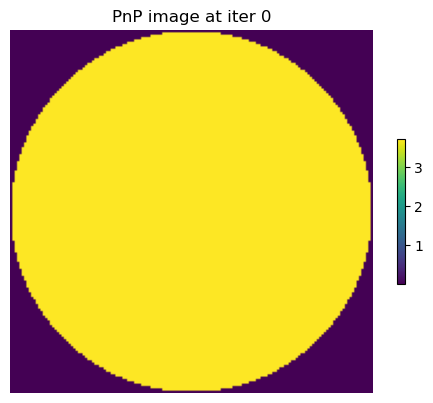

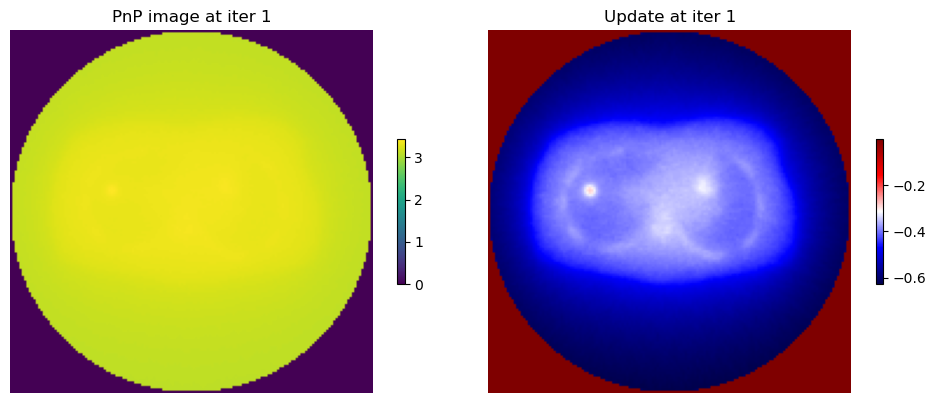

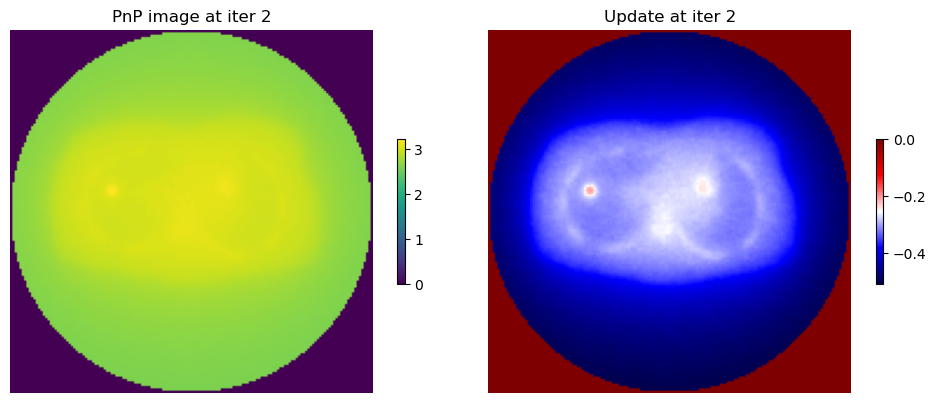

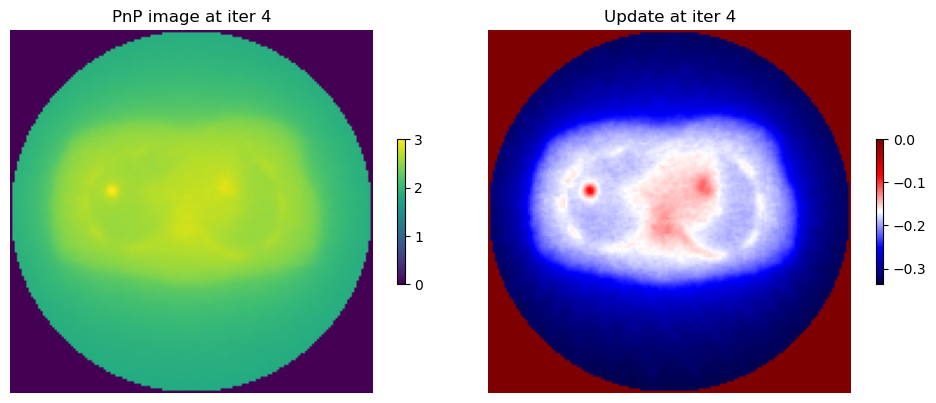

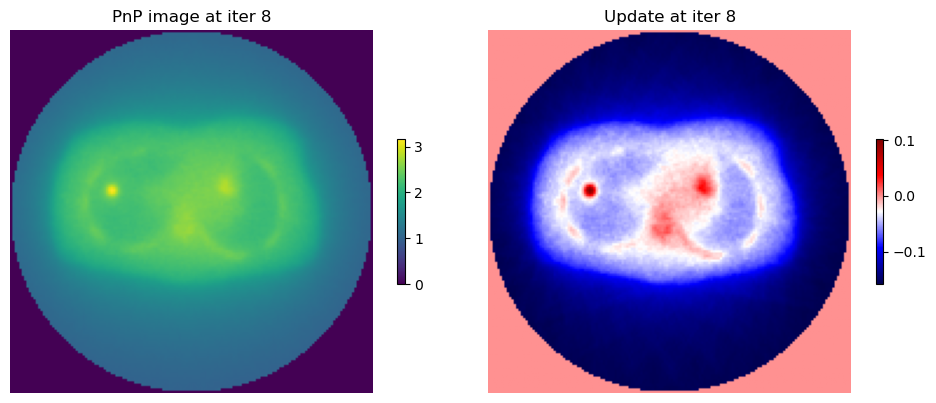

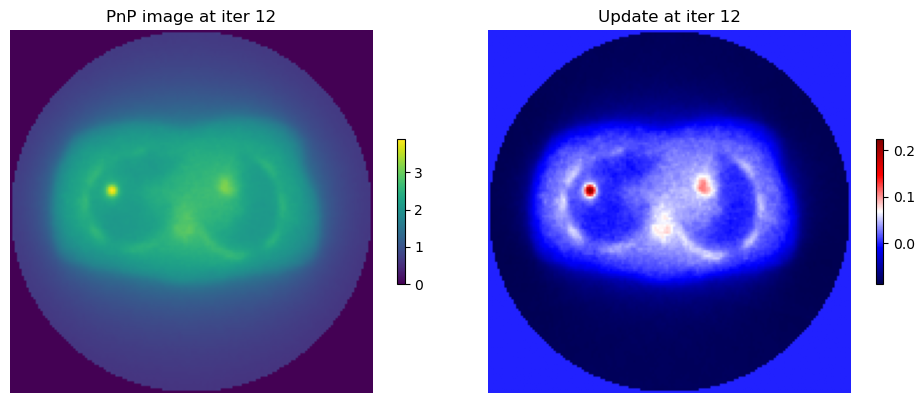

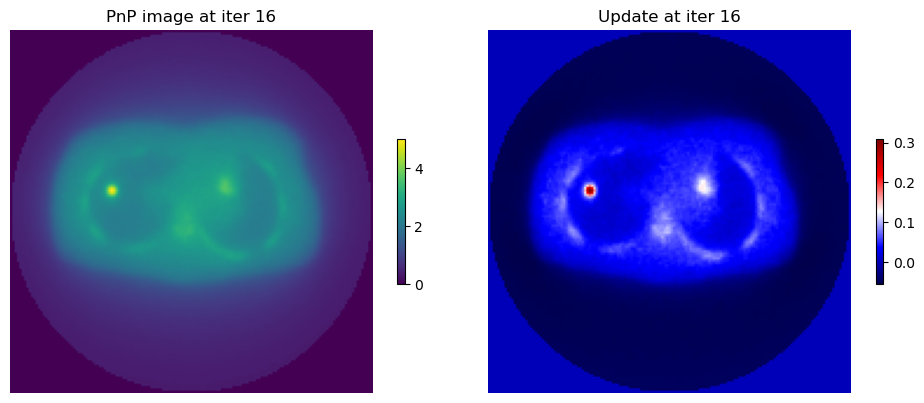

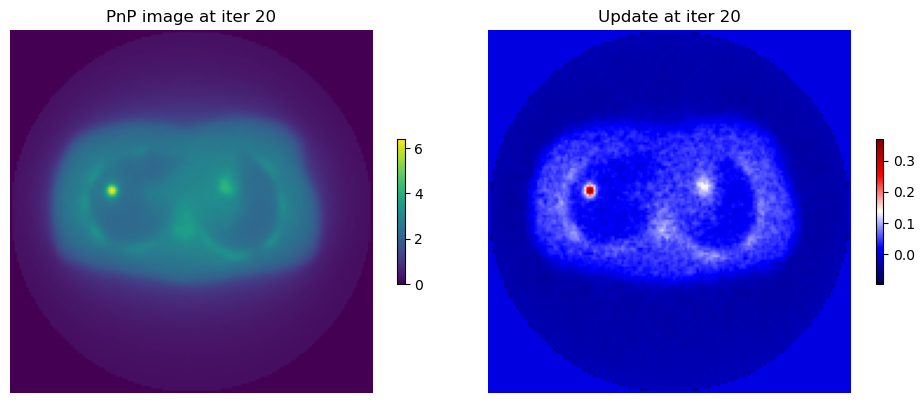

In [26]:
show_iters = [0, 1, 2, 4, 8, 12, 16, 20]

for i in tqdm(show_iters, desc="Reconstructing PnP images"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(all_pnp_images[i, im_slice, :, :], cmap="viridis")
    plt.title(f"PnP image at iter {i}")
    plt.colorbar(shrink=0.4)
    plt.axis("off")

    if i > 0:
        update_img = all_pnp_images[i, im_slice, :, :] - all_pnp_images[i-1, im_slice, :, :]
        plt.subplot(1,2,2)
        plt.imshow(update_img, cmap="seismic")
        plt.title(f"Update at iter {i}")
        plt.colorbar(shrink=0.4)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

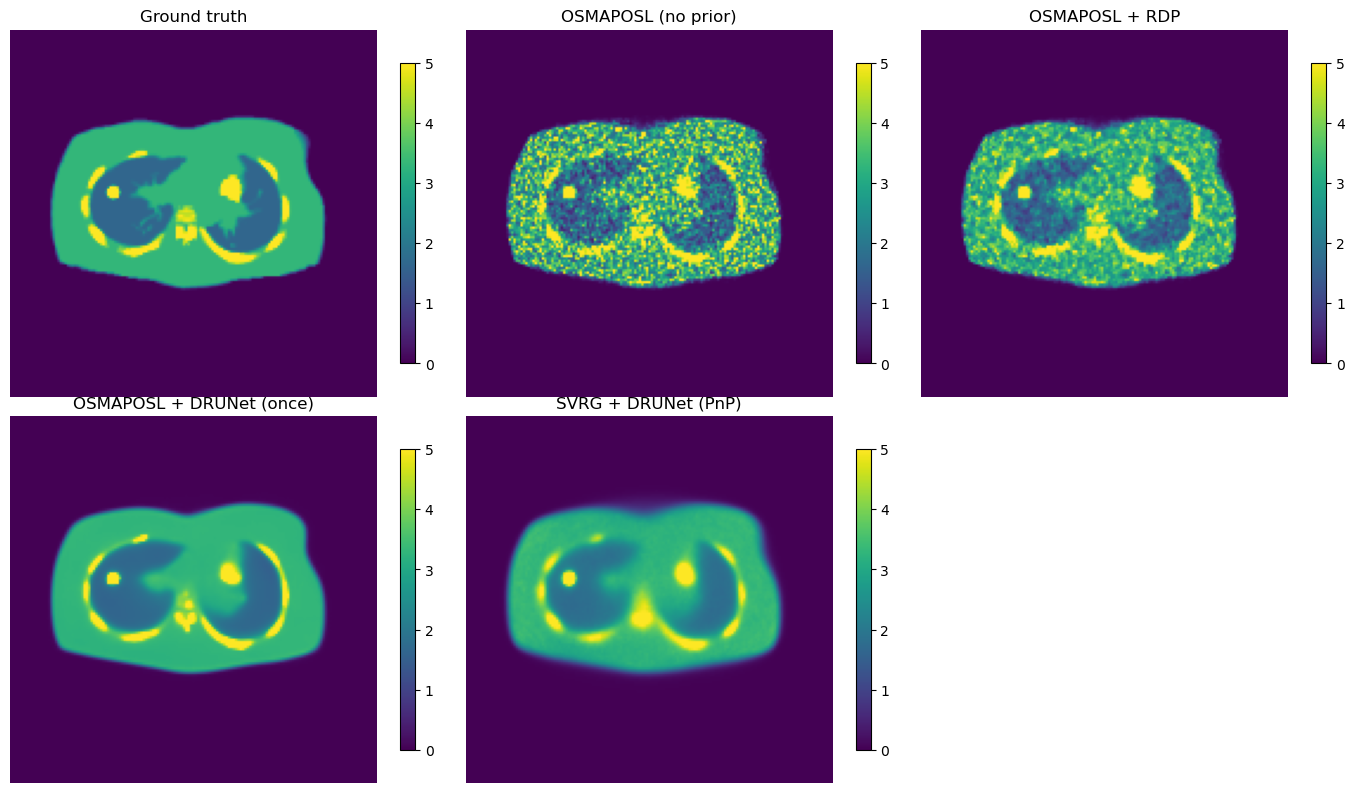

In [27]:
# compare all reconstruction methods

gt_slice = image.as_array()[im_slice, :, :]
no_prior_slice = reconstructed_image_no_prior.as_array()[im_slice, :, :]
rdp_slice = reconstructed_image_rdp.as_array()[im_slice, :, :]
drunet_once_slice = slice2d_denoised
final_pnp = all_pnp_images[-1, im_slice, :, :]

vmin, vmax = 0, 5

plt.figure(figsize=(14,8))

plt.subplot(2,3,1)
plt.imshow(gt_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("Ground truth")
plt.colorbar(shrink=0.8)
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(no_prior_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL (no prior)")
plt.colorbar(shrink=0.8)
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(rdp_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL + RDP")
plt.colorbar(shrink=0.8)
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(drunet_once_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL + DRUNet (once)")
plt.colorbar(shrink=0.8)
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(final_pnp, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("SVRG + DRUNet (PnP)")
plt.colorbar(shrink=0.8)
plt.axis("off")

plt.tight_layout()

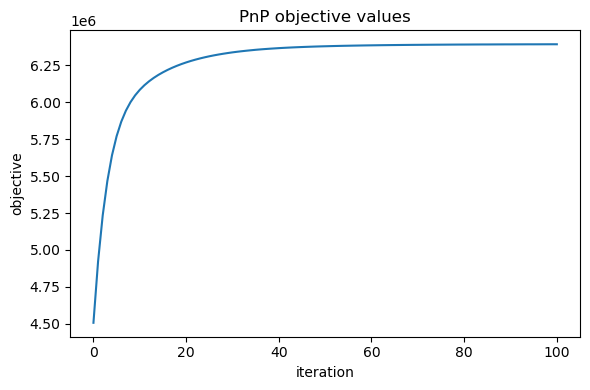

In [28]:
# objective values

plt.figure(figsize=(6,4))
plt.plot(pnp_objective_values)
plt.title("PnP objective values")
plt.xlabel("iteration")
plt.ylabel("objective")
plt.tight_layout()